In [29]:
import cv2
import time
import gymnasium as gym
from google.colab import output
from google.colab.patches import cv2_imshow
mode = "rgb_array"
if mode == "Node":
    mode = None

(15, 9, 0)


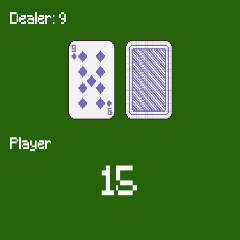

In [30]:
env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
observation, _ = env.reset()

print(f"{observation}")
img = env.render()
w, h, _ = img.shape
ratio = int(h / w)
new_w, new_h = (ratio * 240), 240
cv2_imshow(cv2.resize(img, (new_w, new_h))) #OpenCV

In [31]:
env.action_space, env.observation_space # Przestrzeń akcji i obseracje

(Discrete(2), Tuple(Discrete(32), Discrete(11), Discrete(2)))

In [32]:
from os import truncate
# 0 - pass
# 1 - dobierz kartę
observation, reward, terminated, truncated, info = env.step(1)

In [33]:
observation, reward, terminated, truncated # Jeśli jeden z parametrów true to koniec gry

((25, 9, 0), -1.0, True, False)

In [34]:
env.close()

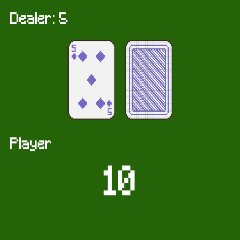

nagroda = 1.0, liczba punktów graczy = 10


In [36]:
def nowa_gra(env):
  observation, info = env.reset()
  img = env.render();
  w, h, _ = img.shape
  ratio = int(h / w)
  new_w, new_h = (ratio * 240), 240
  terminated = False
  truncated = False
  cv2_imshow(cv2.resize(img, (new_w, new_h)))
  time.sleep(0.1)

  if(observation[0] !=21):
    while (not terminated) and (not truncated):
      action = int(input('0 - pas, 1 - dobierz kartę\n'))
      observation, reward, terminated, truncated, info = env.step(action)
      output.clear(wait = True)
      time.sleep(0.1)

      img = env.render();
      cv2_imshow(cv2.resize(img, (new_w, new_h)))
      time.sleep(0.1)
  else:
    observation, reward, terminated, truncated, info = env.step(0)
  print(f"nagroda = {reward}, liczba punktów graczy = {observation[0]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
nowa_gra(env)
env.close()

Q-Learning
TO DO: sprawdz ile razy zwycięży skrypt przy losowaniu akcji

In [64]:
#Bez grafiki

def nowa_gra_sample(env):
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    action = env.action_space.sample()
    print(f"{action}, obserwation, ", end='')
    observation, reward, terminated, truncated, info = env.step(action)
    print(f"{observation}, {reward}, {terminated}")
  print(f"nagroda = {reward}, liczba punktów gracza = {observation[0]}, liczba punktów przeciwnika = {observation[1]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)
nowa_gra_sample(env)
env.close()

0, obserwation, (15, 8, 0), 1.0, True
nagroda = 1.0, liczba punktów gracza = 15, liczba punktów przeciwnika = 8
